<a href="https://colab.research.google.com/github/aimeano/Data-Analyst-Project-Syahrul-Aiman/blob/main/Netflix_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv("/content/NetflixOriginals.csv",encoding="latin1")
df

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi
...,...,...,...,...,...,...
579,Taylor Swift: Reputation Stadium Tour,Concert Film,"December 31, 2018",125,8.4,English
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,"October 9, 2015",91,8.4,English/Ukranian/Russian
581,Springsteen on Broadway,One-man show,"December 16, 2018",153,8.5,English
582,Emicida: AmarElo - It's All For Yesterday,Documentary,"December 8, 2020",89,8.6,Portuguese


In [ ]:
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [ ]:
df.isnull().sum()

,0
Title,0
Genre,0
Premiere,0
Runtime,0
IMDB Score,0
Language,0


In [ ]:
df['Premiere'] = pd.to_datetime(df['Premiere'])


df['year'] = df['Premiere'].dt.year
df['month'] = df['Premiere'].dt.month_name()
df['day'] = df['Premiere'].dt.day_name()

df.head()

ValueError: time data "October 16. 2019" doesn't match format "%B %d, %Y", at position 111. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df['Premiere'] = (df['Premiere'].str.replace(".",",",regex=False))

In [ ]:
df['Premiere'] = pd.to_datetime(df['Premiere'],format = "%B %d, %Y")


df['year'] = df['Premiere'].dt.year
df['month'] = df['Premiere'].dt.month_name()
df['day'] = df['Premiere'].dt.day_name()

df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,year,month,day
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,August,Friday
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,December,Thursday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,October,Friday


In [ ]:
top_genres1 = (df['Genre'].value_counts()).head(10)
print(top_genres1)

Genre
Documentary        159
Drama               77
Comedy              49
Romantic comedy     39
Thriller            33
Comedy-drama        14
Crime drama         11
Horror               9
Biopic               9
Action               7
Name: count, dtype: int64


Q1: What are the most common genres among Netflix Originals?

In [ ]:
top_genres = (df['Genre'].str.split("/").explode().value_counts()).head(10)
print(top_genres)

Genre
Documentary        159
Drama               81
Comedy              57
Romantic comedy     40
Thriller            38
Science fiction     16
Comedy-drama        15
Horror              12
Crime drama         12
Action              11
Name: count, dtype: int64


In [ ]:
top_genres.columns = ["Genre","Count"]
top_genres

,count
Genre,
Documentary,159
Drama,81
Comedy,57
Romantic comedy,40
Thriller,38
Science fiction,16
Comedy-drama,15
Horror,12
Crime drama,12


<function matplotlib.pyplot.show(close=None, block=None)>

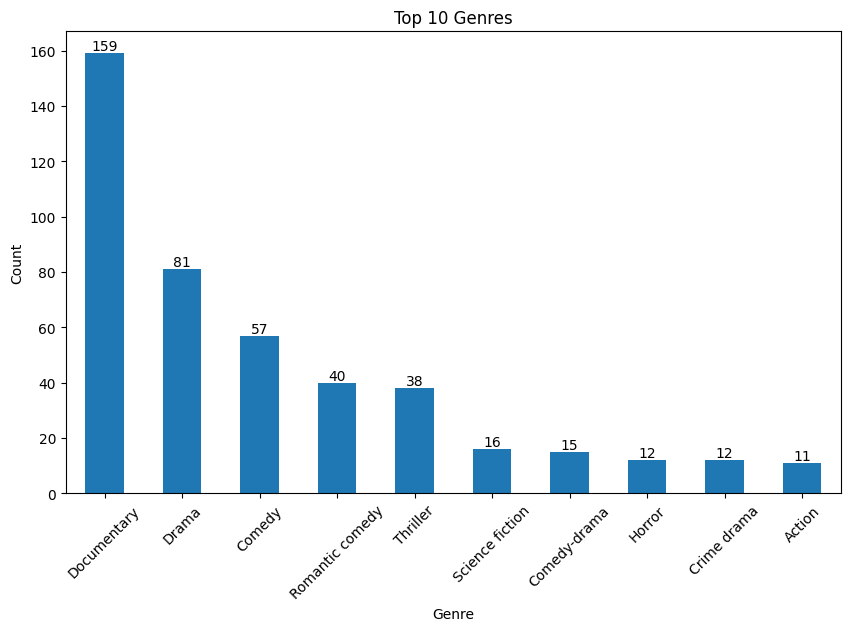

In [ ]:
plt.figure(figsize=(10,6))
bar = top_genres.plot(kind="bar")

bar.bar_label(plt.gca().containers[0])

plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Top 10 Genres")

plt.xticks(rotation=45)
plt.tight_layout

plt.show

Q2: Which year had the highest number of Netflix Original releases?

In [ ]:
top_years = df["year"].value_counts().head(10)
top_years.columns = ["Year","Counts"]
top_years

,count
year,
2020,183
2019,125
2018,99
2021,71
2017,66
2016,30
2015,9
2014,1


Text(0.5, 1.0, 'Top 10 Years')

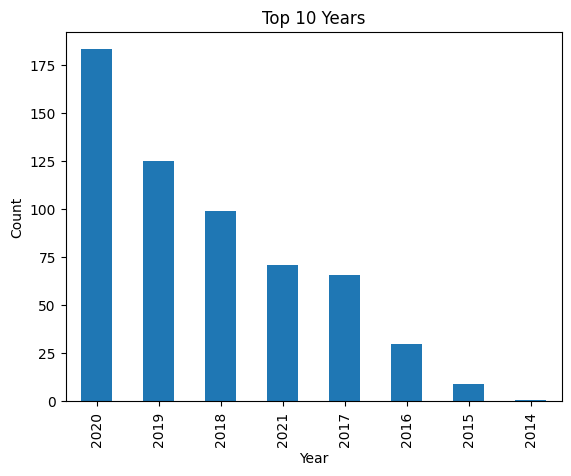

In [ ]:
top_years.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Top 10 Years")

Q3: What is the average IMDb score of all Netflix Originals

In [ ]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,year,month,day
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,August,Friday
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,December,Thursday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,October,Friday


In [ ]:
print("Average IMDB Score:")
print(df["IMDB Score"].mean().round(1))

Average IMDB Score:
6.3


Q4: Which movies or shows have the highest and lowest IMDb scores?

In [ ]:
print("Movies with lowest score:")
lowest_score = df.loc[df["IMDB Score"] == min(df['IMDB Score']),["Title","IMDB Score"]]
print(lowest_score)

Movies with lowest score:
             Title  IMDB Score
0  Enter the Anime         2.5


In [ ]:
print("Movies with highest score:")
higest_score = df.loc[df["IMDB Score"] == max(df['IMDB Score']),["Title","IMDB Score"]]
print(higest_score)

Movies with highest score:
                                        Title  IMDB Score
583  David Attenborough: A Life on Our Planet         9.0


Q5: How many Netflix Originals were released each month?

In [139]:
monthly_releases = (
    df.groupby(['year', 'month'])['Title']
    .count()
    .reset_index(name='Number_of_Releases')
)

print(monthly_releases)

    year     month  Number_of_Releases
0   2014  December                   1
1   2015  December                   2
2   2015      July                   1
3   2015      June                   1
4   2015       May                   2
..   ...       ...                 ...
65  2021     April                  18
66  2021  February                  13
67  2021   January                  16
68  2021     March                  12
69  2021       May                  12

[70 rows x 3 columns]


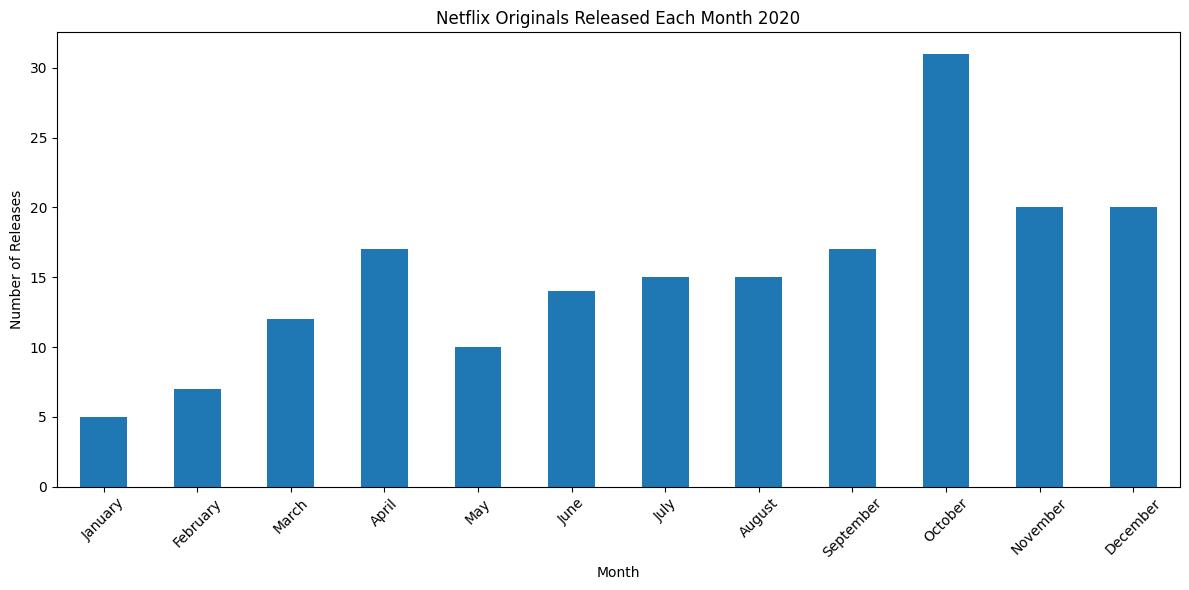

In [150]:
monthly_releases_yearly = (
    df[df['year'] == 2020]['month']
    .value_counts()
)


monthly_releases_yearly= monthly_releases_yearly.reindex([
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12,6))
monthly_releases_yearly.plot(kind='bar')

plt.title('Netflix Originals Released Each Month 2020')
plt.xlabel('Month')
plt.ylabel('Number of Releases')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [151]:
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,year,month,day
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,August,Friday
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,December,Thursday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,October,Friday


Q6: Which language appears most frequently in the dataset?

In [158]:
print("most frequently appeared language:")
freq_lang= df['Language'].str.split("/").explode().value_counts().head(10)
freq_lang

most frequently appeared language:


,count
Language,
English,422
Spanish,39
Hindi,35
French,21
Italian,14
Portuguese,12
Indonesian,9
Japanese,8
Korean,7


<Axes: ylabel='count'>

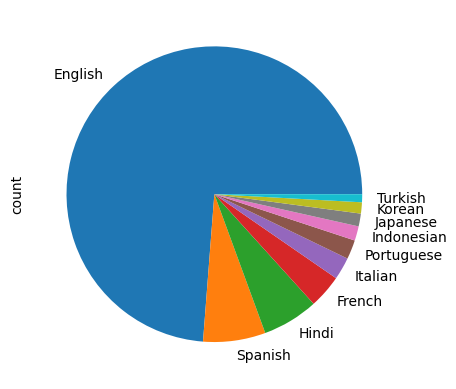

In [159]:
freq_lang.plot(kind='pie')

Q7: What is the average runtime of Netflix Originals?

In [165]:
print("Average runtime:")
print(f"{df['Runtime'].mean().round(2)} minutes")

Average runtime:
93.58 minutes


Q8: Which genres tend to have the longest runtimes?

In [194]:
genre_runtime = (
    df.assign(Genre=df['Genre'].str.split('/'))
    .explode('Genre')
    .groupby('Genre')['Runtime']
    .mean()
    .sort_values(ascending=False)
)

print(genre_runtime.head(10))

Genre
Anthology                       149.0
Heist film                      149.0
Zombie                          148.0
War drama                       145.5
Horror anthology                144.0
Psychological thriller drama    142.0
Historical drama                140.0
Psychological thriller          124.0
Romantic thriller               123.0
Heist                           122.5
Name: Runtime, dtype: float64
